# US Flight Delays at Scale: When to Fly, Aircraft Age, and Predicting Diversions

Every year, millions of US domestic flights arrive late. This project analyses **~35 million flight records** covering 2003–2007 from the [*Data Expo 2009: Airline On-Time Data*](https://doi.org/10.7910/DVN/HG7NV7) dataset (Harvard Dataverse) to answer three questions:

- **When is the best time to fly?** Which day of the week and departure time block give the lowest probability of arriving late?
- **Do older aircraft get delayed more?** Is there a measurable association between aircraft age and delay probability, after controlling for confounders?
- **Can diversions be predicted?** How well can a logistic regression on schedule features anticipate a rare (~0.2%) event?

The pipeline loads each year's CSV in memory-efficient chunks, cleans and feature-engineers the data (delay indicators, departure time blocks, aircraft age from tail-number lookups, airport coordinates), and fits per-year logistic regression models with scikit-learn.

*This project began as university coursework and has since been revised and extended as a personal portfolio piece.*

In [1]:
%matplotlib inline
import os
import warnings
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.ticker as mtick
import seaborn as sns
from sklearn.linear_model import LogisticRegression
from sklearn.preprocessing import StandardScaler, OneHotEncoder
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.model_selection import train_test_split
from sklearn.metrics import roc_auc_score, average_precision_score

sns.set_theme(style="whitegrid", palette="muted", font_scale=1.15)
PALETTE = sns.color_palette("muted")

warnings.filterwarnings("ignore", category=FutureWarning)
warnings.filterwarnings("ignore", category=pd.errors.SettingWithCopyWarning)

## Configuration

In [2]:
DELAY_OUTLIER_UPPER =  360
DELAY_OUTLIER_LOWER = -120

TIME_BLOCKS = {
    "00-05  Night":         (0,    500),
    "05-08  Early Morning": (500,  800),
    "08-12  Morning Peak":  (800,  1200),
    "12-16  Midday":        (1200, 1600),
    "16-20  Afternoon Peak":(1600, 2000),
    "20-24  Evening":       (2000, 2400),
}

DAY_LABELS = {1:"Mon", 2:"Tue", 3:"Wed", 4:"Thu", 5:"Fri", 6:"Sat", 7:"Sun"}

FLIGHT_DTYPES = {
    "Year":              "int16",
    "Month":             "int8",
    "DayofMonth":        "int8",
    "DayOfWeek":         "int8",
    "CRSDepTime":        "int16",
    "CRSArrTime":        "int16",
    "UniqueCarrier":     "category",
    "TailNum":           "object",
    "ActualElapsedTime": "float32",
    "CRSElapsedTime":    "float32",
    "AirTime":           "float32",
    "ArrDelay":          "float32",
    "DepDelay":          "float32",
    "Origin":            "category",
    "Dest":              "category",
    "Distance":          "float32",
    "Cancelled":         "int8",
    "Diverted":          "int8",
}

FLIGHT_COLS = list(FLIGHT_DTYPES.keys())

## Data Loading

Three reference files are used alongside the annual flight CSVs: plane manufacture years, airport coordinates, and carrier codes.

In [3]:
def load_flights(filepath: str, chunksize: int = 500_000) -> pd.DataFrame:
    """Load a year of flight data with dtype optimisation."""
    print(f"  Loading: {filepath}")
    chunks = []
    for chunk in pd.read_csv(
        filepath,
        usecols=FLIGHT_COLS,
        dtype={c: FLIGHT_DTYPES[c] for c in FLIGHT_COLS if c != "TailNum"},
        chunksize=chunksize,
        na_values=["NA", ""],
        low_memory=False,
    ):
        chunks.append(chunk)
    df = pd.concat(chunks, ignore_index=True)
    print(f"    Loaded {len(df):,} rows, {df.memory_usage(deep=True).sum()/1e6:.1f} MB")
    return df


def load_plane_data(filepath: str) -> pd.DataFrame:
    planes = pd.read_csv(filepath, usecols=["tailnum", "year"])
    planes["year"] = pd.to_numeric(planes["year"], errors="coerce")
    planes = planes.dropna(subset=["year"])
    planes["year"] = planes["year"].astype("int16")
    return planes.rename(columns={"year": "ManufactureYear"})


def load_airports(filepath: str) -> pd.DataFrame:
    airports = pd.read_csv(filepath, usecols=["iata", "lat", "long"])
    return airports.dropna()


def load_carriers(filepath: str) -> pd.DataFrame:
    return pd.read_csv(filepath)

## Preprocessing

`clean_flights` removes or flags bad rows: missing arrival delay, implausible AirTime values, and invalid tail numbers. `engineer_features` adds derived columns - delay indicator, time block, aircraft age, and airport coordinates - used across all three analyses.

In [4]:
def clean_flights(df: pd.DataFrame, verbose: bool = True) -> tuple:
    """Fix AirTime issues, drop missing ArrDelay, sanitise TailNum, clamp CRS times.
    Returns (cleaned_df, diverted_rows_df).
    """
    df = df.copy()
    n0 = len(df)

    bad_airtime = (
        df["AirTime"].notna() & df["ActualElapsedTime"].notna()
        & (df["AirTime"] >= df["ActualElapsedTime"])
    )
    if verbose:
        print(f"    AirTime >= ElapsedTime: {bad_airtime.sum():,} rows -> AirTime set NaN")
    df.loc[bad_airtime, "AirTime"] = np.nan

    neg_air = df["AirTime"].notna() & (df["AirTime"] <= 0)
    if verbose:
        print(f"    Negative/zero AirTime:  {neg_air.sum():,} rows -> set NaN")
    df.loc[neg_air, "AirTime"] = np.nan

    diverted_rows = df[df["Diverted"] == 1].copy()

    df = df.dropna(subset=["ArrDelay"])
    if verbose:
        print(f"    Dropped {n0 - len(df):,} rows (missing ArrDelay / cancelled / diverted)")
        print(f"    Remaining: {len(df):,}")

    df["TailNum"] = df["TailNum"].astype(str).str.strip().str.upper()
    invalid_tail = df["TailNum"].isin(["0", "000000", "UNKNOW", "UNKNOWN", "NAN", "NONE", "", "N/A"])
    if verbose:
        print(f"    Invalid TailNum: {invalid_tail.sum():,} -> set NaN")
    df.loc[invalid_tail, "TailNum"] = np.nan

    for col in ["CRSDepTime", "CRSArrTime"]:
        bad = (df[col] < 0) | (df[col] > 2359)
        if verbose and bad.sum():
            print(f"    {col} out of range: {bad.sum():,} rows -> NaN")
        df.loc[bad, col] = np.nan

    return df, diverted_rows


def assign_time_block(crs_dep_time: pd.Series) -> pd.Series:
    """Map HHMM scheduled departure time to time block label."""
    result = pd.Series("Unknown", index=crs_dep_time.index, dtype="object")
    for label, (lo, hi) in TIME_BLOCKS.items():
        result.loc[(crs_dep_time >= lo) & (crs_dep_time < hi)] = label
    return result.astype("category")


def engineer_features(
    df: pd.DataFrame,
    plane_df: pd.DataFrame,
    airport_df: pd.DataFrame,
    flight_year: int,
) -> pd.DataFrame:
    """Add DelayIndicator, time block, aircraft age, and airport coordinates."""
    df = df.copy()

    df["DelayIndicator"] = (df["ArrDelay"] > 0).astype("int8")
    df["DepHour"]   = (df["CRSDepTime"] // 100).clip(0, 23)
    df["TimeBlock"] = assign_time_block(df["CRSDepTime"])
    df["DayLabel"]  = df["DayOfWeek"].map(DAY_LABELS)
    df["DepMinutes"] = (df["CRSDepTime"] // 100) * 60 + (df["CRSDepTime"] % 100)
    df["ArrMinutes"] = (df["CRSArrTime"] // 100) * 60 + (df["CRSArrTime"] % 100)

    df = df.merge(
        plane_df.rename(columns={"tailnum": "TailNum"}),
        on="TailNum", how="left"
    )
    df["AircraftAge"] = flight_year - df["ManufactureYear"]
    df.loc[df["AircraftAge"] < 0,  "AircraftAge"] = np.nan
    df.loc[df["AircraftAge"] > 60, "AircraftAge"] = np.nan

    coord = airport_df.set_index("iata")
    df["OriginLat"] = df["Origin"].map(coord["lat"])
    df["OriginLon"] = df["Origin"].map(coord["long"])
    df["DestLat"]   = df["Dest"].map(coord["lat"])
    df["DestLon"]   = df["Dest"].map(coord["long"])

    return df

## Best Time to Fly — Delay Patterns by Day and Time Block

For each year, delay probability (P(ArrDelay > 0)) is computed across all 42 day × time-block combinations to identify the joint minimum. A robustness check repeats the analysis using a stricter delay definition (ArrDelay > 15 min).

In [5]:
def analyze_delay_patterns(df: pd.DataFrame, year: int) -> dict:
    """Compute delay probability by day and time block; identify best combination."""
    print(f"\n{'='*60}")
    print(f"  Delay Patterns by Day & Time Block  --  Year {year}")
    print(f"{'='*60}")

    day_order   = ["Mon", "Tue", "Wed", "Thu", "Fri", "Sat", "Sun"]
    block_order = list(TIME_BLOCKS.keys())
    results     = {}

    # Marginal: by day
    day_stats = (
        df.groupby("DayLabel", observed=True)
          .agg(
              DelayProb   = ("DelayIndicator", "mean"),
              MedianDelay = ("ArrDelay",       "median"),
              N           = ("ArrDelay",       "count"),
          )
          .reindex(day_order)
          .reset_index()
    )
    results["by_day"]  = day_stats
    results["best_day"] = day_stats.loc[day_stats["DelayProb"].idxmin(), "DayLabel"]

    # Marginal: by time block
    block_stats = (
        df.groupby("TimeBlock", observed=True)
          .agg(
              DelayProb   = ("DelayIndicator", "mean"),
              MedianDelay = ("ArrDelay",       "median"),
              N           = ("ArrDelay",       "count"),
          )
          .reindex(block_order)
          .reset_index()
    )
    results["by_block"]  = block_stats
    results["best_block"] = block_stats.loc[block_stats["DelayProb"].idxmin(), "TimeBlock"]

    # Joint: Day x TimeBlock
    cross = (
        df.groupby(["DayLabel", "TimeBlock"], observed=True)["DelayIndicator"]
          .agg(["mean", "count"])
          .reset_index()
          .rename(columns={"mean": "DelayProb", "count": "N"})
    )
    cross_robust = cross[cross["N"] >= 30].copy()
    best_row     = cross_robust.loc[cross_robust["DelayProb"].idxmin()]
    results["best_combination"]      = (best_row["DayLabel"], str(best_row["TimeBlock"]))
    results["best_combination_prob"] = best_row["DelayProb"]
    results["cross"] = cross

    # Robustness: ArrDelay > 15 min
    df2 = df.copy()
    df2["DelayIndicator15"] = (df2["ArrDelay"] > 15).astype("int8")
    cross15 = (
        df2.groupby(["DayLabel", "TimeBlock"], observed=True)["DelayIndicator15"]
           .agg(["mean", "count"])
           .reset_index()
           .rename(columns={"mean": "DelayProb15", "count": "N"})
    )
    cross15_robust = cross15[cross15["N"] >= 30]
    best_row15 = cross15_robust.loc[cross15_robust["DelayProb15"].idxmin()]
    results["best_combination_15min"] = (best_row15["DayLabel"], str(best_row15["TimeBlock"]))
    same_combo = results["best_combination"] == results["best_combination_15min"]
    results["robust_check_same"] = same_combo

    # Console output
    combo    = results["best_combination"]
    combo_15 = results["best_combination_15min"]
    prob_pct = results["best_combination_prob"] * 100
    robust   = "YES" if same_combo else "NO  (changed under >15 min definition)"

    print(f"  Best day   (marginal):      {results['best_day']}")
    print(f"  Best block (marginal):      {results['best_block']}")
    print()
    print(f"  >> MAIN RESULT: Best (Day x Block) combination <<")
    print(f"     Day:         {combo[0]}")
    print(f"     Time Block:  {combo[1]}")
    print(f"     Delay Prob:  {prob_pct:.2f}%")
    print()
    print(f"  Robustness check (ArrDelay > 15 min definition):")
    print(f"     Best combo:  {combo_15[0]} + {combo_15[1]}")
    print(f"     Robust:      {robust}")

    # Visualisation: heatmap + robustness comparison
    short = {b: b.split("  ")[0] for b in block_order}
    heat_df = (
        cross.pivot(index="DayLabel", columns="TimeBlock", values="DelayProb")
             .reindex(index=day_order, columns=block_order)
             .rename(columns=short)
    ) * 100

    block15_stats = (
        df2.groupby("TimeBlock", observed=True)
           .agg(DelayProb15=("DelayIndicator15", "mean"))
           .reindex(block_order)
           .reset_index()
    )

    fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 5))
    fig.suptitle(f"Delay Patterns by Day & Time Block ({year})",
                 fontsize=13, fontweight="bold")

    sns.heatmap(
        heat_df, ax=ax1, cmap="RdYlGn_r",
        annot=True, fmt=".1f", linewidths=0.4,
        cbar_kws={"label": "P(ArrDelay > 0) [%]"}
    )
    ax1.set_title("Delay Probability % - Day x Time Block")
    ax1.set_xlabel("Departure Time Block")
    ax1.set_ylabel("Day of Week")
    ax1.tick_params(axis="x", rotation=25)

    short_labels = [b.split("  ")[0] for b in block_order]
    x     = np.arange(len(block_order))
    width = 0.35
    ax2.bar(x - width/2, block_stats["DelayProb"] * 100,
            width, label="ArrDelay > 0 min", color=PALETTE[0], edgecolor="white")
    ax2.bar(x + width/2, block15_stats["DelayProb15"] * 100,
            width, label="ArrDelay > 15 min", color=PALETTE[2], edgecolor="white")
    ax2.set_xticks(x)
    ax2.set_xticklabels(short_labels, rotation=20)
    ax2.set_title("Robustness: Delay Definition >0 vs >15 min")
    ax2.set_ylabel("Delay Probability [%]")
    ax2.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax2.legend()

    plt.tight_layout()
    plt.show()

    return results

**Key findings:** Sunday early-morning departures (05:00-08:00) have the lowest delay probability in every year, ranging from 25% in 2003 to 32% in 2007. Saturday consistently scores best by day in isolation, and the early-morning block wins by time in all years. The combination is robust to the stricter 15-min threshold in 2004-2006; minor shifts in 2003 and 2007 likely reflect period-specific congestion rather than a breakdown in the pattern.

## Aircraft Age and Delay Probability

Two-part analysis: a descriptive scatter (delay probability by exact aircraft age, with a flight-weighted OLS trend) and a 5-year cohort bar chart. Then a logistic regression controls for month, day of week, departure time, distance, carrier, and airport location - giving an adjusted odds ratio (OR) for a +5-year increase in aircraft age.

> The regression captures association, not causation. Maintenance quality, route type, and fleet composition are not controlled for.

In [6]:
def analyze_aircraft_age(df: pd.DataFrame, year: int) -> dict:
    """
    Descriptive: Pearson r and delay probability by age/cohort.
    Logistic regression: AircraftAge coefficient, controlling for scheduling and route factors.
    Fits on a stratified subsample (max 300k rows) with a held-out 20% test split.
    """
    print(f"\n{'='*60}")
    print(f"  Aircraft Age vs Delay Probability  --  Year {year}")
    print(f"{'='*60}")

    df_b = df.dropna(subset=["AircraftAge"]).copy()
    print(f"  Rows with valid AircraftAge: {len(df_b):,} "
          f"({len(df_b)/len(df)*100:.1f}% of cleaned data)")

    # Descriptive
    by_age = (
        df_b.groupby("AircraftAge")
            .agg(DelayProb=("DelayIndicator", "mean"),
                 N        =("DelayIndicator", "count"))
            .reset_index()
    )
    corr = np.corrcoef(
        np.repeat(by_age["AircraftAge"], by_age["N"]),
        np.repeat(by_age["DelayProb"],   by_age["N"])
    )[0, 1]
    print(f"  Pearson r (age vs delay prob, flight-weighted): {corr:.4f}")
    print(f"  Note: Pearson r is descriptive only; logistic regression is the primary model.")

    bins   = list(range(0, 61, 5))
    labels = [f"{b}-{b+4}" for b in bins[:-1]]
    df_b["AgeCohort"] = pd.cut(df_b["AircraftAge"], bins=bins, labels=labels, right=False)
    by_cohort = (
        df_b.groupby("AgeCohort", observed=True)
            .agg(DelayProb  =("DelayIndicator", "mean"),
                 MedianDelay=("ArrDelay",        "median"),
                 N          =("DelayIndicator",  "count"))
            .reset_index()
    )

    # Logistic regression
    numeric_feats = ["AircraftAge", "Distance", "DepMinutes",
                     "OriginLat", "OriginLon", "DestLat", "DestLon"]
    cat_feats     = ["Month", "DayOfWeek", "UniqueCarrier"]
    req           = numeric_feats + cat_feats + ["DelayIndicator"]

    df_model = df_b.dropna(subset=req).copy()
    for c in cat_feats:
        df_model[c] = df_model[c].astype(str)

    MAX_ROWS = 300_000
    if len(df_model) > MAX_ROWS:
        total = len(df_model)
        parts = []
        for _, grp in df_model.groupby("DelayIndicator"):
            n_sample = int(MAX_ROWS * len(grp) / total)
            parts.append(grp.sample(n=n_sample, random_state=42))
        df_model = (
            pd.concat(parts)
              .sample(frac=1, random_state=42)
              .reset_index(drop=True)
        )
        print(f"  Subsampled to {len(df_model):,} rows (stratified) for model fitting")

    X = df_model[numeric_feats + cat_feats]
    y = df_model["DelayIndicator"]
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_feats),
    ], remainder="drop")

    pipe = Pipeline([
        ("prep",   preprocessor),
        ("logreg", LogisticRegression(
            solver="lbfgs", class_weight="balanced",
            max_iter=300, random_state=42, C=1.0,
        )),
    ])
    pipe.fit(X_train, y_train)

    y_prob  = pipe.predict_proba(X_test)[:, 1]
    roc_auc = roc_auc_score(y_test, y_prob)
    pr_auc  = average_precision_score(y_test, y_prob)

    cat_names = (
        pipe.named_steps["prep"]
            .named_transformers_["cat"]
            .get_feature_names_out(cat_feats)
            .tolist()
    )
    coef_df = pd.DataFrame({
        "Feature":     numeric_feats + cat_names,
        "Coefficient": pipe.named_steps["logreg"].coef_[0],
    })

    # OR for +5 years: back out raw coefficient from standardised scale
    age_coef_std  = float(coef_df.loc[coef_df["Feature"] == "AircraftAge", "Coefficient"].iloc[0])
    age_sd        = df_model["AircraftAge"].std()
    age_coef_raw  = age_coef_std / age_sd
    odds_ratio_5yr = float(np.exp(5 * age_coef_raw))

    print(f"\n  Adjusted Logistic Regression (association only -- not causal):")
    print(f"    AircraftAge coef (standardised): {age_coef_std:+.4f}")
    print(f"    Odds ratio per +5 years older:   {odds_ratio_5yr:.4f}")
    print(f"    ROC-AUC (test):                  {roc_auc:.4f}")
    print(f"    PR-AUC  (test):                  {pr_auc:.4f}")
    print(f"  Note: route type and maintenance quality are not controlled for.")

    # Visualisation
    fig, axes = plt.subplots(1, 2, figsize=(15, 5))
    fig.suptitle(f"Aircraft Age vs Delay Probability ({year})",
                 fontsize=14, fontweight="bold")

    ax = axes[0]
    sc = ax.scatter(by_age["AircraftAge"], by_age["DelayProb"] * 100,
                    s=np.sqrt(by_age["N"]) * 2, alpha=0.65,
                    c=by_age["AircraftAge"], cmap="viridis", edgecolors="none")
    z  = np.polyfit(np.repeat(by_age["AircraftAge"], by_age["N"]),
                    np.repeat(by_age["DelayProb"],   by_age["N"]), 1)
    xr = np.linspace(by_age["AircraftAge"].min(), by_age["AircraftAge"].max(), 100)
    ax.plot(xr, np.polyval(z, xr) * 100, "r--", linewidth=1.8,
            label=f"OLS trend (r={corr:.2f})")
    ax.set_xlabel("Aircraft Age (years)")
    ax.set_ylabel("P(ArrDelay > 0)  [%]")
    ax.set_title("Delay Probability by Exact Age\n(bubble size proportional to flight count)")
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())
    ax.legend()
    plt.colorbar(sc, ax=ax, label="Age")

    ax = axes[1]
    ax.bar(by_cohort["AgeCohort"].astype(str),
           by_cohort["DelayProb"] * 100,
           color=PALETTE, edgecolor="white")
    ax.set_xlabel("Aircraft Age Cohort (years)")
    ax.set_ylabel("P(ArrDelay > 0)  [%]")
    ax.set_title(
        f"Delay Probability by 5-Year Cohort\n"
        f"OR(+5 yr) = {odds_ratio_5yr:.4f}  |  ROC-AUC = {roc_auc:.4f}  |  PR-AUC = {pr_auc:.4f}"
    )
    ax.tick_params(axis="x", rotation=30)
    ax.yaxis.set_major_formatter(mtick.PercentFormatter())

    plt.tight_layout()
    plt.show()

    return {
        "correlation":    corr,
        "by_age":         by_age,
        "by_cohort":      by_cohort,
        "age_coef_std":   age_coef_std,
        "age_coef_raw":   age_coef_raw,
        "odds_ratio_5yr": odds_ratio_5yr,
        "roc_auc":        roc_auc,
        "pr_auc":         pr_auc,
        "coef_df":        coef_df,
    }

**Key findings:** After adjusting for scheduling and route factors, older aircraft are weakly but consistently associated with higher delay probability. The OR per +5 years rises from 1.01 in 2003 to 1.04 in 2007 - a real but modest effect. Models achieve ROC-AUC in the range 0.59-0.63, confirming the association exists but aircraft age alone explains only a small share of delay variance once other factors are held fixed.

## Predicting Flight Diversions

Fits a logistic regression for P(Diverted = 1). Diverted rows excluded from the delay analyses above are re-included here. Features: departure/arrival minutes, distance, airport coordinates, day of month, month, day of week, and carrier.

Diversions are rare (~0.2% of flights), so **PR-AUC is the primary metric** - it is more informative than ROC-AUC when the positive class is heavily underrepresented.

In [7]:
def build_diversion_dataset(
    df_flights_clean: pd.DataFrame,
    diverted_rows: pd.DataFrame,
    airport_df: pd.DataFrame,
    plane_df: pd.DataFrame,
    flight_year: int,
) -> pd.DataFrame:
    """Rebuild dataset including diverted flights for diversion modelling."""
    div_feat    = engineer_features(diverted_rows, plane_df, airport_df, flight_year)
    shared_cols = [c for c in df_flights_clean.columns if c in div_feat.columns]
    return pd.concat(
        [df_flights_clean[shared_cols], div_feat[shared_cols]],
        ignore_index=True
    )


def fit_diversion_model(df: pd.DataFrame, year: int, max_iter: int = 1000) -> dict:
    """Fit logistic regression for P(Diverted=1) with stratified train/test split."""
    print(f"\n{'='*60}")
    print(f"  Diversion Logistic Regression  --  Year {year}")
    print(f"{'='*60}")

    df = df.copy()
    numeric_feats = ["DepMinutes", "ArrMinutes", "Distance",
                     "OriginLat", "OriginLon", "DestLat", "DestLon", "DayofMonth"]
    cat_feats = ["Month", "DayOfWeek", "UniqueCarrier"]
    target    = "Diverted"
    all_feat  = numeric_feats + cat_feats

    df_model = df.dropna(subset=all_feat + [target]).copy()
    for c in cat_feats:
        df_model[c] = df_model[c].astype(str)

    div_rate = df_model[target].mean()
    print(f"  Full dataset:   {len(df_model):,} rows")
    print(f"  Diverted rate:  {div_rate*100:.3f}%")
    if df_model[target].sum() < 20:
        print("  WARNING: fewer than 20 diversions -- model may not converge.")

    # Keep all diverted rows; downsample majority class only
    MAX_SAMPLE = 200_000
    if len(df_model) > MAX_SAMPLE:
        n_div    = int(df_model[target].sum())
        n_normal = MAX_SAMPLE - n_div
        df_div    = df_model[df_model[target] == 1]
        df_normal = df_model[df_model[target] == 0].sample(n=n_normal, random_state=42)
        df_model  = (
            pd.concat([df_div, df_normal])
              .sample(frac=1, random_state=42)
              .reset_index(drop=True)
        )
        print(f"  Subsampled to:  {len(df_model):,} rows "
              f"({n_div} diverted + {n_normal} non-diverted)")

    X = df_model[all_feat]
    y = df_model[target].astype(int)
    X_train, X_test, y_train, y_test = train_test_split(
        X, y, test_size=0.2, random_state=42, stratify=y
    )

    preprocessor = ColumnTransformer([
        ("num", StandardScaler(), numeric_feats),
        ("cat", OneHotEncoder(handle_unknown="ignore", sparse_output=False), cat_feats),
    ], remainder="drop")

    pipe = Pipeline([
        ("prep",   preprocessor),
        ("logreg", LogisticRegression(
            solver="lbfgs", class_weight="balanced",
            max_iter=max_iter, C=1.0, random_state=42,
        )),
    ])
    pipe.fit(X_train, y_train)

    y_prob      = pipe.predict_proba(X_test)[:, 1]
    roc_auc     = roc_auc_score(y_test, y_prob)     if y_test.nunique() > 1 else np.nan
    pr_auc      = average_precision_score(y_test, y_prob) if y_test.nunique() > 1 else np.nan
    baseline_pr = float(y_test.mean())

    print(f"  ROC-AUC (test):   {roc_auc:.4f}")
    print(f"  PR-AUC  (test):   {pr_auc:.4f}  (baseline = {baseline_pr:.4f})")

    cat_names = (
        pipe.named_steps["prep"]
            .named_transformers_["cat"]
            .get_feature_names_out(cat_feats)
            .tolist()
    )
    all_feature_names = numeric_feats + cat_names
    coef_df = pd.DataFrame({
        "Feature":     all_feature_names,
        "Coefficient": pipe.named_steps["logreg"].coef_[0],
        "Year":        year,
    }).sort_values("Coefficient", ascending=False)

    # Plot top-20 coefficients
    plot_df = coef_df.head(20) if len(coef_df) > 20 else coef_df
    fig, ax = plt.subplots(figsize=(9, 7))
    colors = ["#d62728" if c > 0 else "#1f77b4" for c in plot_df["Coefficient"]]
    ax.barh(plot_df["Feature"], plot_df["Coefficient"], color=colors)
    ax.axvline(0, color="black", linewidth=0.8)
    ax.set_title(
        f"Logistic Regression Coefficients - P(Diverted), {year}\n"
        f"(numeric features standardised; categoricals one-hot encoded)\n"
        f"ROC-AUC = {roc_auc:.4f}  |  PR-AUC = {pr_auc:.4f}"
    )
    ax.set_xlabel("Coefficient (standardised numeric scale)")
    plt.tight_layout()
    plt.show()

    return {
        "year":          year,
        "coef_df":       coef_df,
        "roc_auc":       roc_auc,
        "pr_auc":        pr_auc,
        "baseline_pr":   baseline_pr,
        "model":         pipe,
        "feature_names": all_feature_names,
    }


def plot_multi_year_coefficients(model_results: list) -> None:
    """Plot how numeric feature coefficients evolve across years."""
    if not model_results:
        print("No model results to plot.")
        return

    all_coefs = pd.concat([r["coef_df"] for r in model_results], ignore_index=True)
    years     = sorted(all_coefs["Year"].unique())

    focus_features = ["DepMinutes", "ArrMinutes", "Distance",
                      "OriginLat", "OriginLon", "DestLat", "DestLon", "DayofMonth"]
    plot_data = all_coefs[all_coefs["Feature"].isin(focus_features)]

    fig, ax = plt.subplots(figsize=(12, 6))
    for feat, grp in plot_data.groupby("Feature"):
        ax.plot(grp["Year"], grp["Coefficient"], marker="o", linewidth=2, label=feat)
    ax.axhline(0, color="black", linewidth=0.8, linestyle="--")
    ax.set_xticks(years)
    ax.set_xlabel("Year")
    ax.set_ylabel("Standardised Coefficient")
    ax.set_title(
        "Diversion Model Coefficients Across Years\n"
        "(numeric features only, standardised scale)"
    )
    ax.legend(bbox_to_anchor=(1.01, 1), loc="upper left", fontsize=9)
    plt.tight_layout()
    plt.show()

    print("\n  Model metrics by year (test set):")
    print(f"  {'Year':>6}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'Baseline PR':>11}")
    print(f"  {'-'*6}  {'-'*8}  {'-'*8}  {'-'*11}")
    for r in sorted(model_results, key=lambda x: x["year"]):
        bl = r.get("baseline_pr", float("nan"))
        print(f"  {r['year']:>6}  {r['roc_auc']:>8.4f}  {r['pr_auc']:>8.4f}  {bl:>11.4f}")

**Key findings:** The diversion model consistently beats the naive baseline across all years (e.g. PR-AUC 0.097 vs baseline 0.057 in 2003, rising to 0.159 vs 0.086 in 2007). ROC-AUC sits steadily at ~0.65-0.68. The diversion rate itself grew from 0.18% to 0.24% over the period. The multi-year coefficient plot shows the model structure is stable across years, suggesting the predictors are not year-specific artefacts.

## Pipeline

`run_analysis` orchestrates the full pipeline: loads each year's data, runs all three analyses, and prints summary tables. Update `DATA_DIR` below to match your local copy of the flight data (see the README for download instructions).

In [8]:
def run_analysis(
    flight_files: list,
    plane_file:   str,
    airport_file: str,
    carrier_file: str,
) -> dict:
    """Master pipeline: load data, run all three analyses, print summaries."""
    print("=" * 70)
    print("  AIRLINE ANALYSIS PIPELINE  --  ASA Data Expo")
    print("=" * 70)

    print("\nLoading reference tables...")
    plane_df   = load_plane_data(plane_file)
    airport_df = load_airports(airport_file)
    carrier_df = load_carriers(carrier_file)
    print(f"  Planes: {len(plane_df):,}  |  Airports: {len(airport_df):,}"
          f"  |  Carriers: {len(carrier_df):,}")

    delay_results = {}
    age_results = {}
    diversion_models  = []

    for fpath in flight_files:
        print(f"\n{'─'*60}")
        print(f"  Processing: {os.path.basename(fpath)}")
        print(f"{'─'*60}")

        raw  = load_flights(fpath)
        year = int(raw["Year"].mode().iloc[0])
        print(f"  Detected year: {year}")

        cleaned, diverted_rows = clean_flights(raw)
        df = engineer_features(cleaned, plane_df, airport_df, year)

        delay_results[year] = analyze_delay_patterns(df, year)
        age_results[year] = analyze_aircraft_age(df, year)

        df_qc        = build_diversion_dataset(df, diverted_rows, airport_df, plane_df, year)
        model_result = fit_diversion_model(df_qc, year)
        diversion_models.append(model_result)

        del raw, cleaned

    plot_multi_year_coefficients(diversion_models)

    # Summary tables
    print("\n" + "=" * 70)
    print("  SUMMARY  --  Best Day, Time Block & Combination by Year")
    print("=" * 70)
    print(f"  {'Year':>4}  {'Best Day':>8}  {'Best Block':<24}  {'Best Combo (Day + Block)':<40}  Robust")
    print(f"  {'-'*4}  {'-'*8}  {'-'*24}  {'-'*40}  {'-'*6}")
    for yr, res in sorted(delay_results.items()):
        combo     = res["best_combination"]
        combo_str = f"{combo[0]} + {combo[1]}"
        robust    = "YES" if res["robust_check_same"] else "NO"
        print(
            f"  {yr:>4}  {res['best_day']:>8}  {str(res['best_block']):<24}  "
            f"{combo_str:<40}  {robust}"
        )

    print("\n" + "=" * 70)
    print("  SUMMARY  --  Aircraft Age Association (Adjusted Logistic Regression)")
    print("=" * 70)
    print(f"  {'Year':>4}  {'Pearson r':>9}  {'Coef (std)':>10}  {'OR (+5 yr)':>10}  {'ROC-AUC':>8}  {'PR-AUC':>7}")
    print(f"  {'-'*4}  {'-'*9}  {'-'*10}  {'-'*10}  {'-'*8}  {'-'*7}")
    for yr, res in sorted(age_results.items()):
        print(
            f"  {yr:>4}  {res['correlation']:>+9.4f}  "
            f"{res['age_coef_std']:>+10.4f}  "
            f"{res['odds_ratio_5yr']:>10.4f}  "
            f"{res['roc_auc']:>8.4f}  "
            f"{res['pr_auc']:>7.4f}"
        )

    print("\n" + "=" * 70)
    print("  SUMMARY  --  Diversion Model Metrics by Year (test set)")
    print("=" * 70)
    print(f"  {'Year':>4}  {'ROC-AUC':>8}  {'PR-AUC':>8}  {'Baseline PR':>11}")
    print(f"  {'-'*4}  {'-'*8}  {'-'*8}  {'-'*11}")
    for r in sorted(diversion_models, key=lambda x: x["year"]):
        bl = r.get("baseline_pr", float("nan"))
        print(f"  {r['year']:>4}  {r['roc_auc']:>8.4f}  {r['pr_auc']:>8.4f}  {bl:>11.4f}")

    return {"delay_patterns": delay_results, "aircraft_age": age_results, "diversion_models": diversion_models}

  AIRLINE ANALYSIS PIPELINE  --  ASA Data Expo

Loading reference tables...
  Planes: 4,335  |  Airports: 3,376  |  Carriers: 1,491

────────────────────────────────────────────────────────────
  Processing: 2003.csv
────────────────────────────────────────────────────────────
  Loading: ./data\2003.csv


    Loaded 6,488,540 rows, 1586.9 MB
  Detected year: 2003


    AirTime >= ElapsedTime: 258,025 rows -> AirTime set NaN
    Negative/zero AirTime:  3,968 rows -> set NaN


    Dropped 112,851 rows (missing ArrDelay / cancelled / diverted)
    Remaining: 6,375,689


    Invalid TailNum: 62 -> set NaN
    CRSDepTime out of range: 1 rows -> NaN
    CRSArrTime out of range: 26 rows -> NaN



  Delay Patterns by Day & Time Block  --  Year 2003


  Best day   (marginal):      Sat
  Best block (marginal):      05-08  Early Morning

  >> MAIN RESULT: Best (Day x Block) combination <<
     Day:         Sun
     Time Block:  05-08  Early Morning
     Delay Prob:  25.10%

  Robustness check (ArrDelay > 15 min definition):
     Best combo:  Thu + 00-05  Night
     Robust:      NO  (changed under >15 min definition)


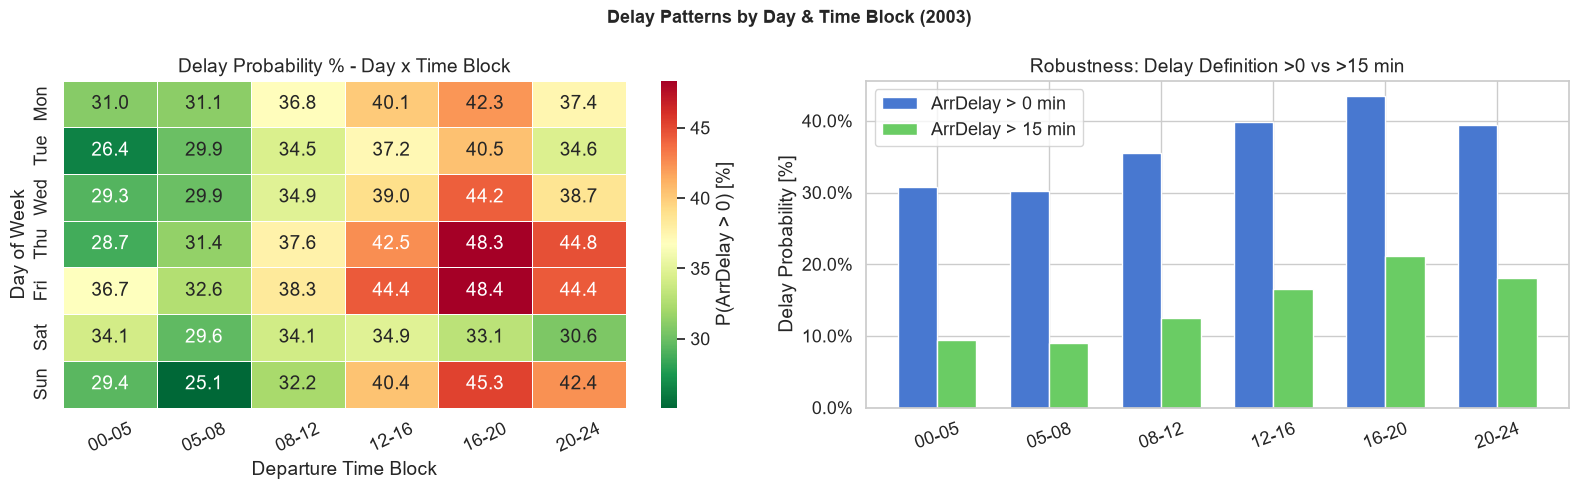


  Aircraft Age vs Delay Probability  --  Year 2003


  Rows with valid AircraftAge: 3,293,279 (51.7% of cleaned data)


  Pearson r (age vs delay prob, flight-weighted): -0.1018
  Note: Pearson r is descriptive only; logistic regression is the primary model.


  Subsampled to 299,999 rows (stratified) for model fitting



  Adjusted Logistic Regression (association only -- not causal):
    AircraftAge coef (standardised): +0.0175
    Odds ratio per +5 years older:   1.0115
    ROC-AUC (test):                  0.5913
    PR-AUC  (test):                  0.4747
  Note: route type and maintenance quality are not controlled for.


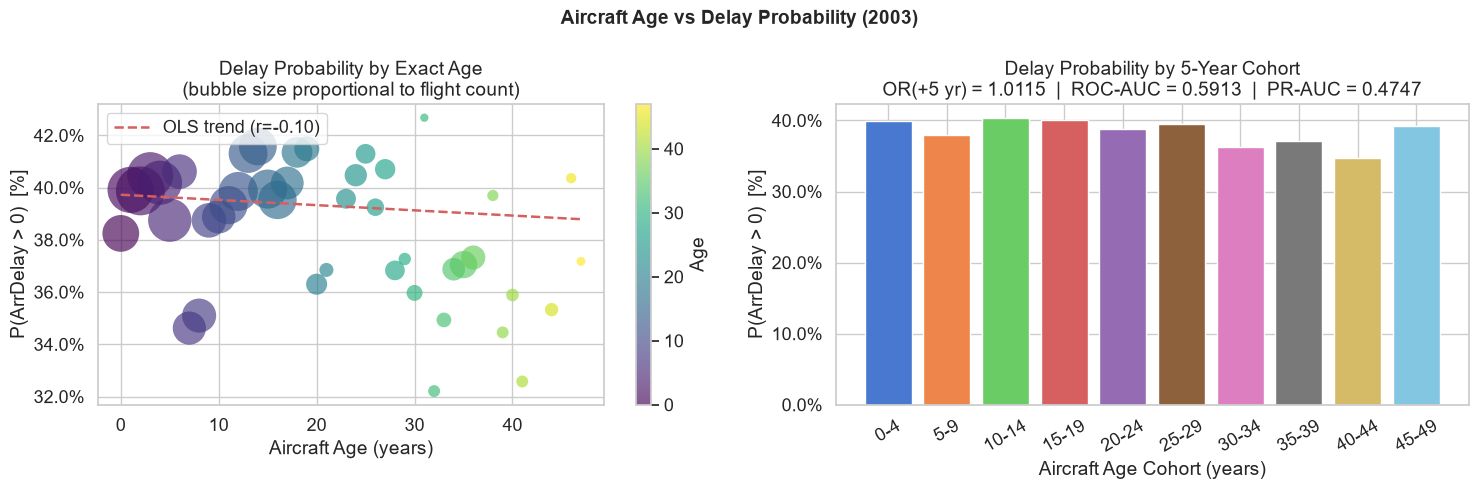


  Diversion Logistic Regression  --  Year 2003


  Full dataset:   6,387,043 rows
  Diverted rate:  0.178%


  Subsampled to:  200,000 rows (11381 diverted + 188619 non-diverted)


  ROC-AUC (test):   0.6543
  PR-AUC  (test):   0.0971  (baseline = 0.0569)


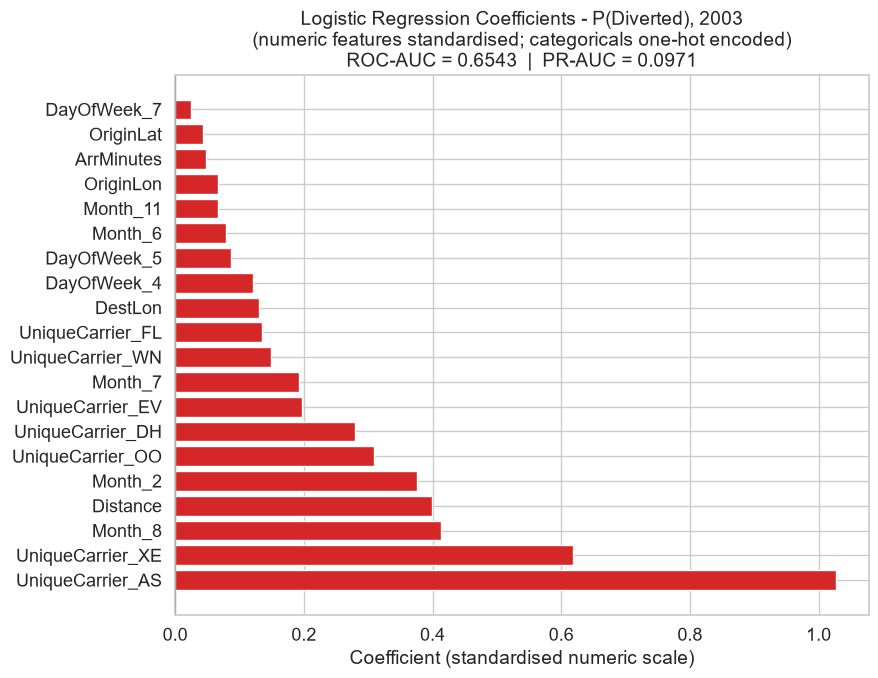


────────────────────────────────────────────────────────────
  Processing: 2004.csv
────────────────────────────────────────────────────────────
  Loading: ./data\2004.csv


    Loaded 7,129,270 rows, 1745.0 MB
  Detected year: 2004


    AirTime >= ElapsedTime: 189,761 rows -> AirTime set NaN
    Negative/zero AirTime:  9,524 rows -> set NaN


    Dropped 141,541 rows (missing ArrDelay / cancelled / diverted)
    Remaining: 6,987,729


    Invalid TailNum: 548 -> set NaN
    CRSArrTime out of range: 4 rows -> NaN



  Delay Patterns by Day & Time Block  --  Year 2004


  Best day   (marginal):      Sat
  Best block (marginal):      05-08  Early Morning

  >> MAIN RESULT: Best (Day x Block) combination <<
     Day:         Sun
     Time Block:  05-08  Early Morning
     Delay Prob:  27.72%

  Robustness check (ArrDelay > 15 min definition):
     Best combo:  Sun + 05-08  Early Morning
     Robust:      YES


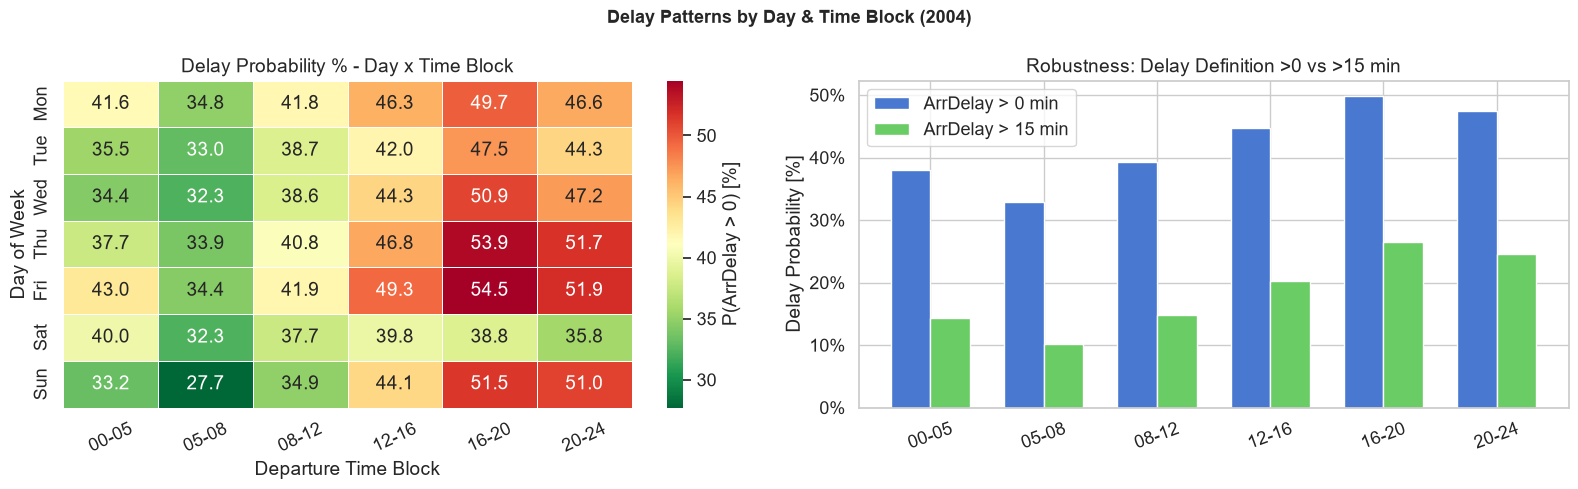


  Aircraft Age vs Delay Probability  --  Year 2004


  Rows with valid AircraftAge: 4,389,789 (62.8% of cleaned data)


  Pearson r (age vs delay prob, flight-weighted): 0.6397
  Note: Pearson r is descriptive only; logistic regression is the primary model.


  Subsampled to 299,999 rows (stratified) for model fitting



  Adjusted Logistic Regression (association only -- not causal):
    AircraftAge coef (standardised): +0.0250
    Odds ratio per +5 years older:   1.0172
    ROC-AUC (test):                  0.6026
    PR-AUC  (test):                  0.5238
  Note: route type and maintenance quality are not controlled for.


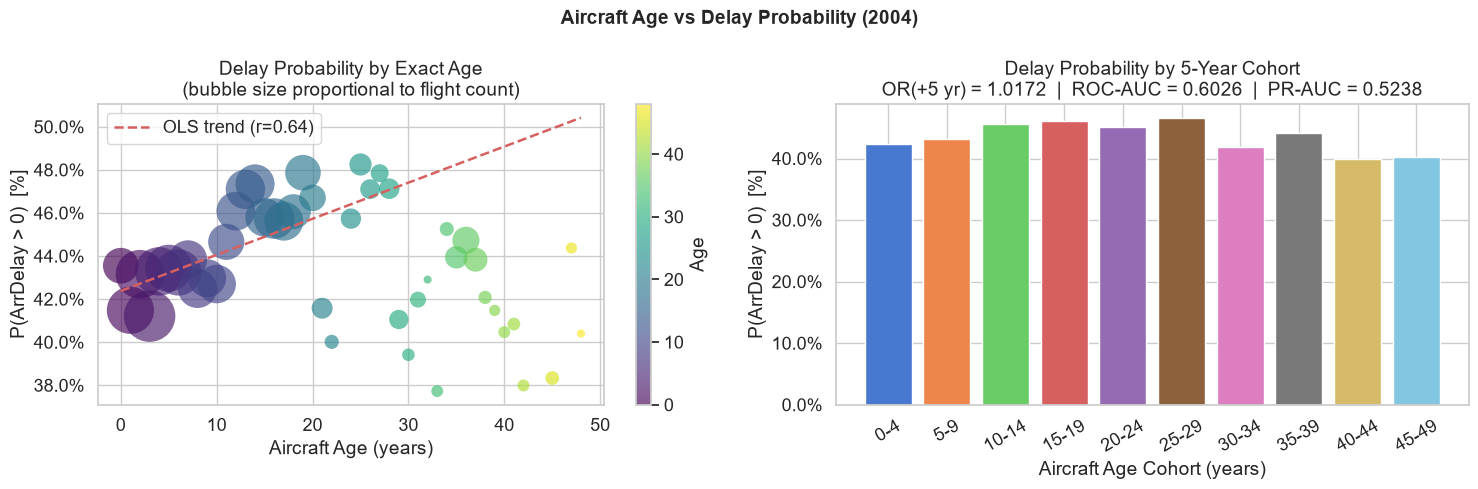


  Diversion Logistic Regression  --  Year 2004


  Full dataset:   7,001,508 rows
  Diverted rate:  0.197%


  Subsampled to:  200,000 rows (13784 diverted + 186216 non-diverted)


  ROC-AUC (test):   0.6460
  PR-AUC  (test):   0.1129  (baseline = 0.0689)


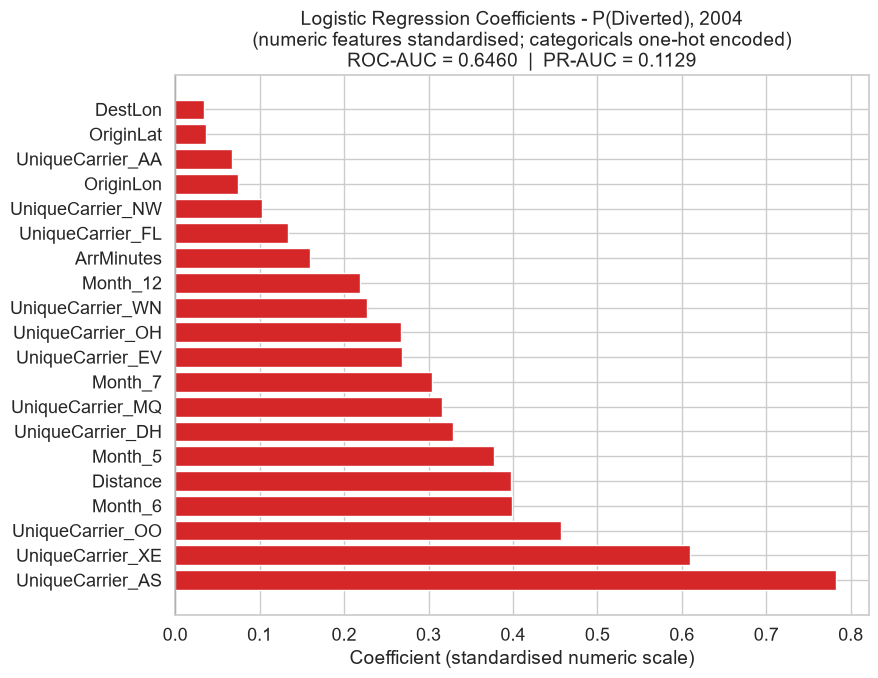


────────────────────────────────────────────────────────────
  Processing: 2005.csv
────────────────────────────────────────────────────────────
  Loading: ./data\2005.csv


    Loaded 7,140,596 rows, 1747.7 MB
  Detected year: 2005


    AirTime >= ElapsedTime: 24,076 rows -> AirTime set NaN
    Negative/zero AirTime:  6,594 rows -> set NaN


    Dropped 147,758 rows (missing ArrDelay / cancelled / diverted)
    Remaining: 6,992,838


    Invalid TailNum: 56 -> set NaN



  Delay Patterns by Day & Time Block  --  Year 2005


  Best day   (marginal):      Sat
  Best block (marginal):      05-08  Early Morning

  >> MAIN RESULT: Best (Day x Block) combination <<
     Day:         Sun
     Time Block:  05-08  Early Morning
     Delay Prob:  27.51%

  Robustness check (ArrDelay > 15 min definition):
     Best combo:  Sun + 05-08  Early Morning
     Robust:      YES


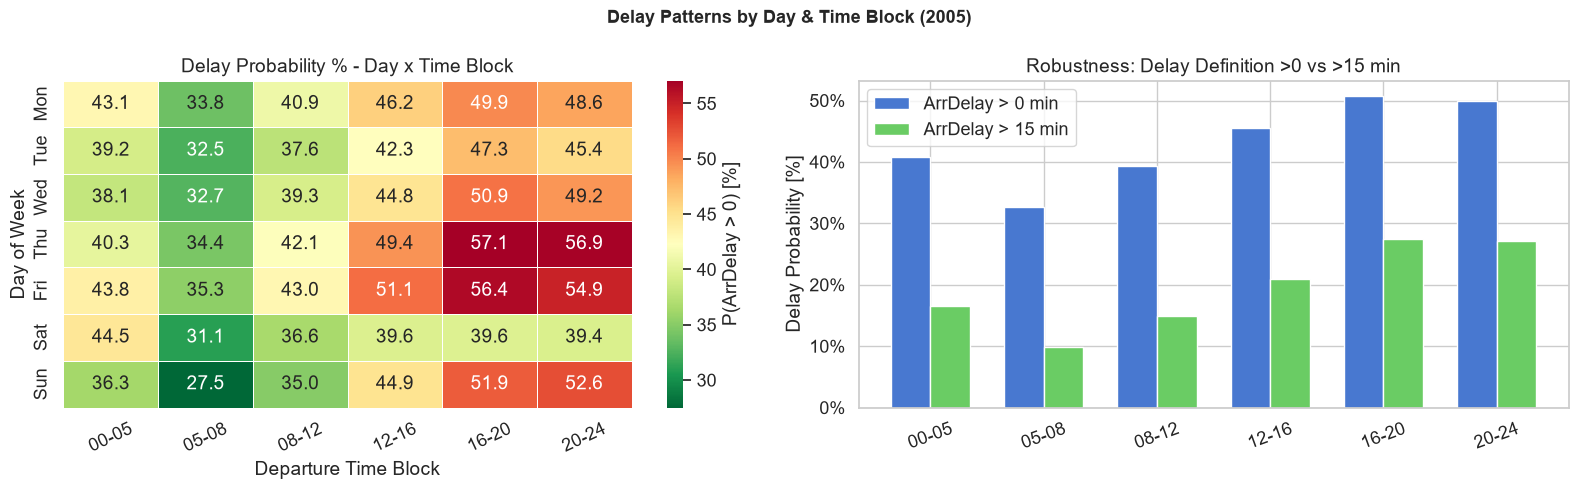


  Aircraft Age vs Delay Probability  --  Year 2005


  Rows with valid AircraftAge: 4,920,216 (70.4% of cleaned data)


  Pearson r (age vs delay prob, flight-weighted): 0.4992
  Note: Pearson r is descriptive only; logistic regression is the primary model.


  Subsampled to 299,999 rows (stratified) for model fitting



  Adjusted Logistic Regression (association only -- not causal):
    AircraftAge coef (standardised): +0.0343
    Odds ratio per +5 years older:   1.0238
    ROC-AUC (test):                  0.6106
    PR-AUC  (test):                  0.5428
  Note: route type and maintenance quality are not controlled for.


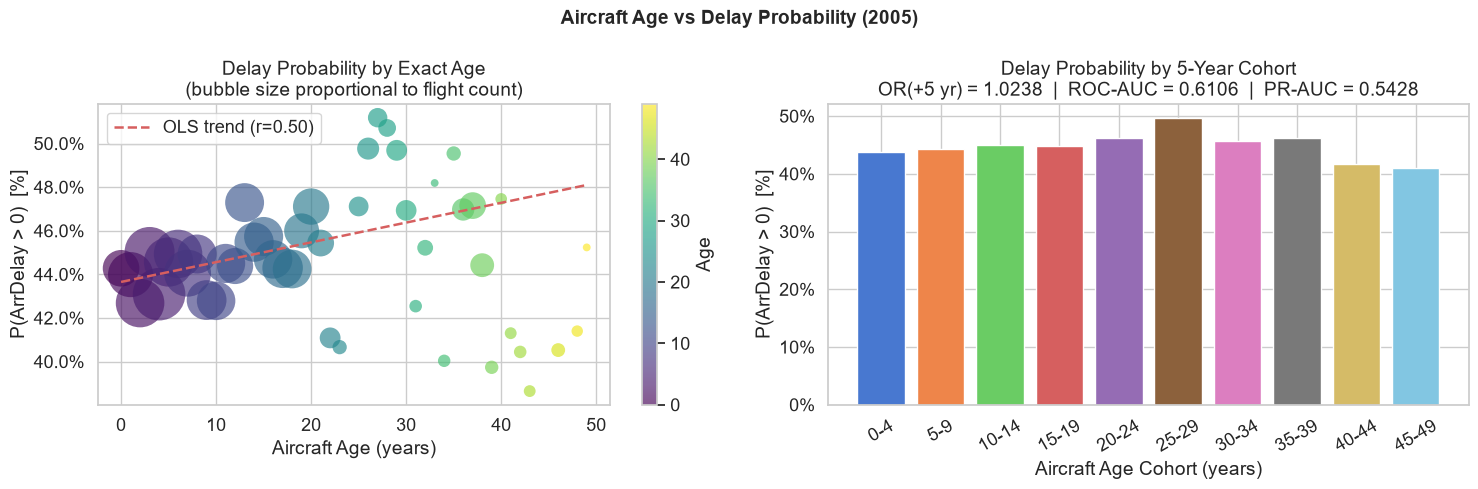


  Diversion Logistic Regression  --  Year 2005


  Full dataset:   7,006,866 rows
  Diverted rate:  0.200%


  Subsampled to:  200,000 rows (14028 diverted + 185972 non-diverted)


  ROC-AUC (test):   0.6671
  PR-AUC  (test):   0.1255  (baseline = 0.0702)


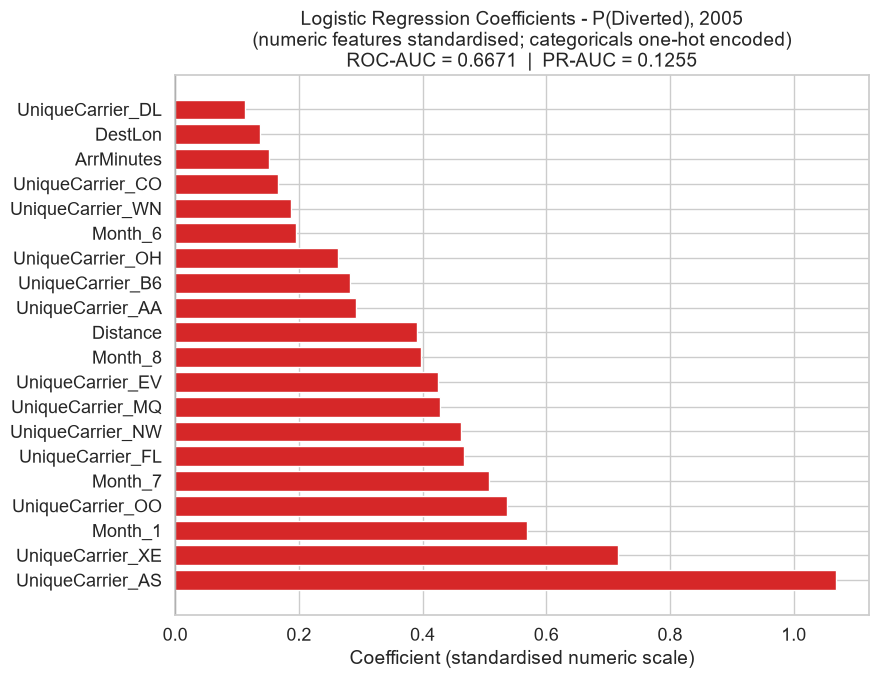


────────────────────────────────────────────────────────────
  Processing: 2006.csv
────────────────────────────────────────────────────────────
  Loading: ./data\2006.csv


    Loaded 7,141,922 rows, 1747.9 MB
  Detected year: 2006


    AirTime >= ElapsedTime: 28,458 rows -> AirTime set NaN
    Negative/zero AirTime:  3,311 rows -> set NaN


    Dropped 138,120 rows (missing ArrDelay / cancelled / diverted)
    Remaining: 7,003,802


    Invalid TailNum: 159 -> set NaN



  Delay Patterns by Day & Time Block  --  Year 2006


  Best day   (marginal):      Sat
  Best block (marginal):      05-08  Early Morning

  >> MAIN RESULT: Best (Day x Block) combination <<
     Day:         Sun
     Time Block:  05-08  Early Morning
     Delay Prob:  29.00%

  Robustness check (ArrDelay > 15 min definition):
     Best combo:  Sun + 05-08  Early Morning
     Robust:      YES


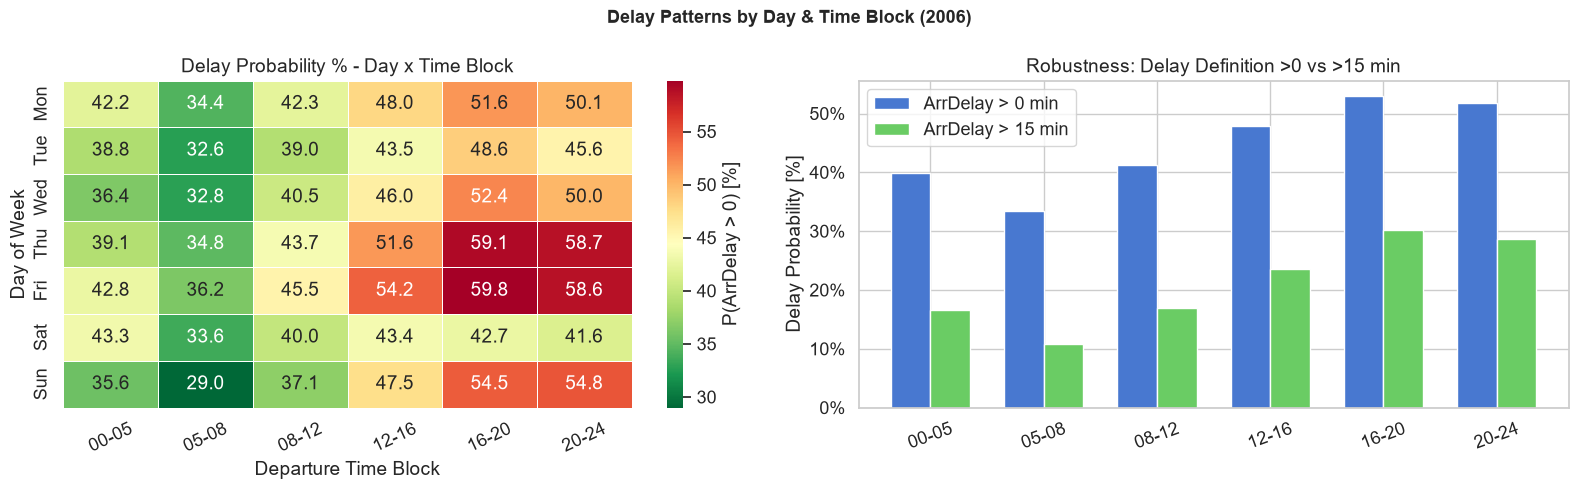


  Aircraft Age vs Delay Probability  --  Year 2006


  Rows with valid AircraftAge: 5,300,168 (75.7% of cleaned data)


  Pearson r (age vs delay prob, flight-weighted): 0.2282
  Note: Pearson r is descriptive only; logistic regression is the primary model.


  Subsampled to 299,999 rows (stratified) for model fitting



  Adjusted Logistic Regression (association only -- not causal):
    AircraftAge coef (standardised): +0.0410
    Odds ratio per +5 years older:   1.0286
    ROC-AUC (test):                  0.5970
    PR-AUC  (test):                  0.5496
  Note: route type and maintenance quality are not controlled for.


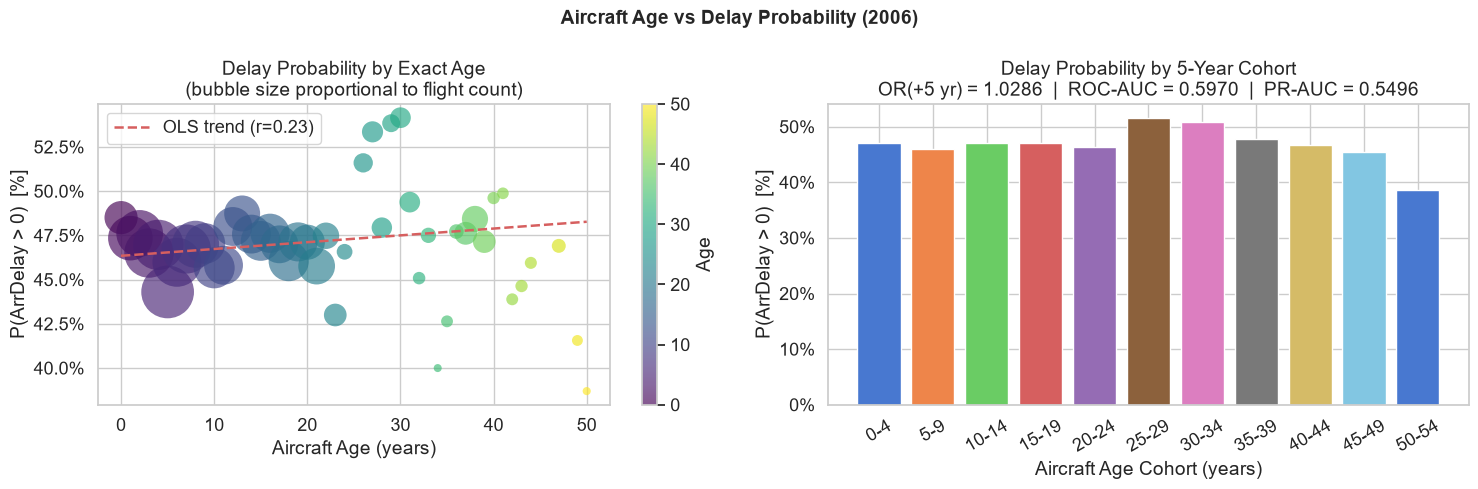


  Diversion Logistic Regression  --  Year 2006


  Full dataset:   7,019,988 rows
  Diverted rate:  0.231%


  Subsampled to:  200,000 rows (16186 diverted + 183814 non-diverted)


  ROC-AUC (test):   0.6664
  PR-AUC  (test):   0.1446  (baseline = 0.0809)


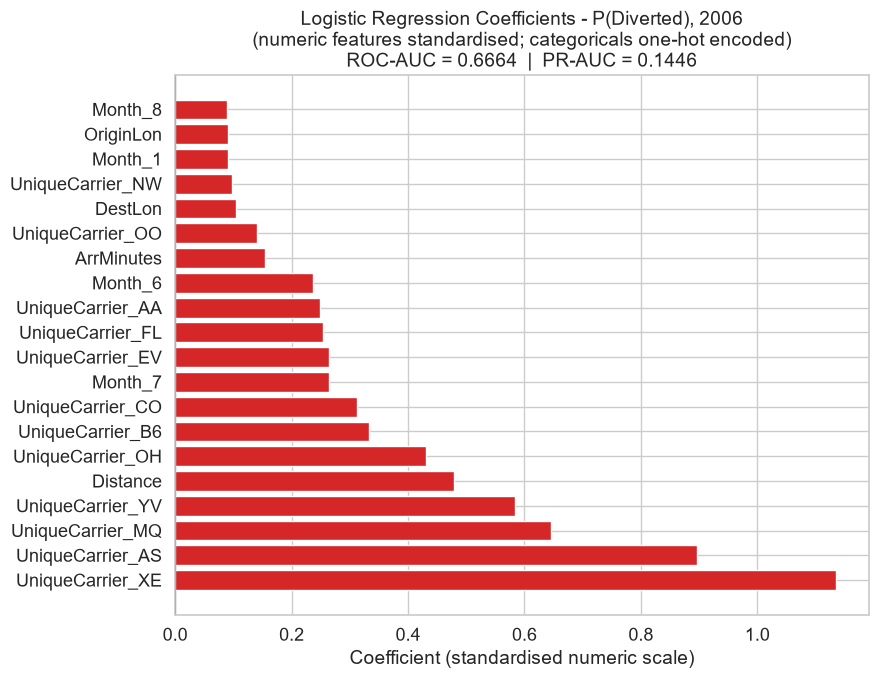


────────────────────────────────────────────────────────────
  Processing: 2007.csv
────────────────────────────────────────────────────────────
  Loading: ./data\2007.csv


    Loaded 7,453,215 rows, 1825.3 MB
  Detected year: 2007


    AirTime >= ElapsedTime: 7 rows -> AirTime set NaN
    Negative/zero AirTime:  97 rows -> set NaN


    Dropped 177,927 rows (missing ArrDelay / cancelled / diverted)
    Remaining: 7,275,288


    Invalid TailNum: 15 -> set NaN



  Delay Patterns by Day & Time Block  --  Year 2007


  Best day   (marginal):      Sat
  Best block (marginal):      05-08  Early Morning

  >> MAIN RESULT: Best (Day x Block) combination <<
     Day:         Sun
     Time Block:  05-08  Early Morning
     Delay Prob:  32.45%

  Robustness check (ArrDelay > 15 min definition):
     Best combo:  Tue + 05-08  Early Morning
     Robust:      NO  (changed under >15 min definition)


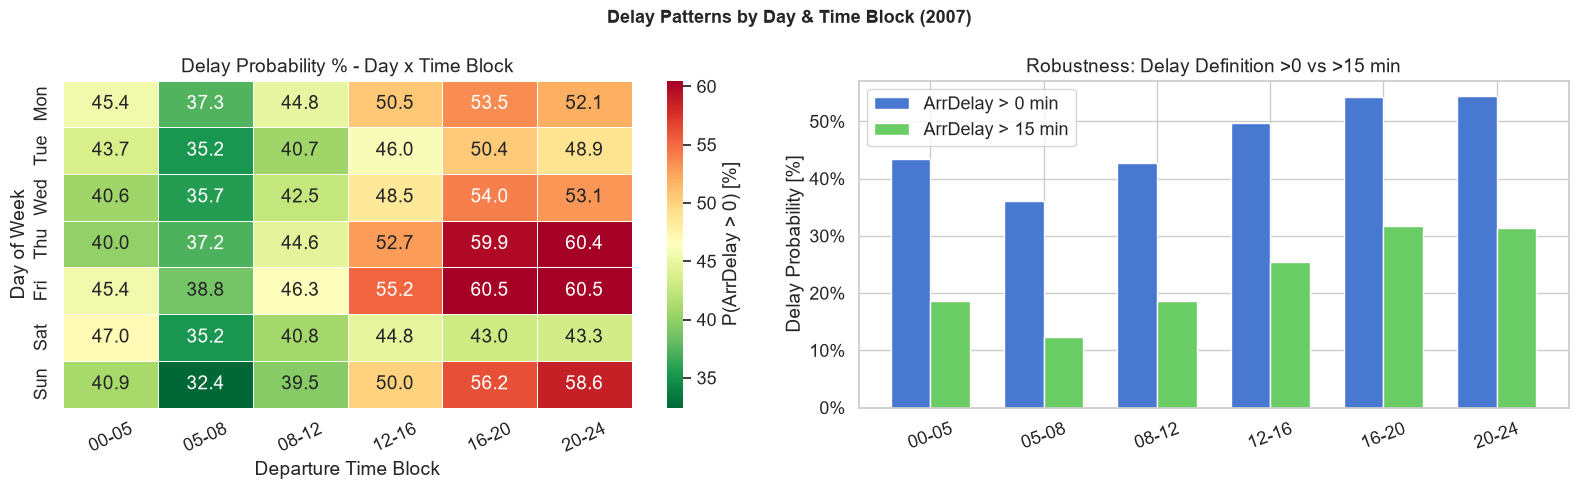


  Aircraft Age vs Delay Probability  --  Year 2007


  Rows with valid AircraftAge: 6,261,500 (86.1% of cleaned data)


  Pearson r (age vs delay prob, flight-weighted): 0.7562
  Note: Pearson r is descriptive only; logistic regression is the primary model.


  Subsampled to 299,999 rows (stratified) for model fitting



  Adjusted Logistic Regression (association only -- not causal):
    AircraftAge coef (standardised): +0.0607
    Odds ratio per +5 years older:   1.0425
    ROC-AUC (test):                  0.6261
    PR-AUC  (test):                  0.5823
  Note: route type and maintenance quality are not controlled for.


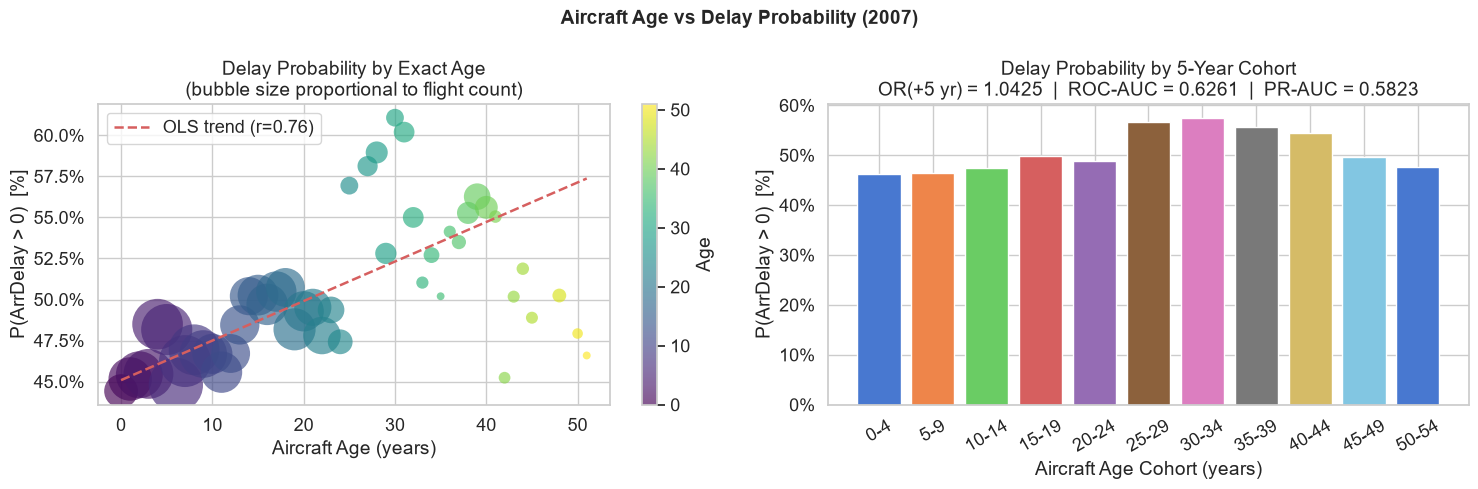


  Diversion Logistic Regression  --  Year 2007


  Full dataset:   7,292,467 rows
  Diverted rate:  0.236%


  Subsampled to:  200,000 rows (17179 diverted + 182821 non-diverted)


  ROC-AUC (test):   0.6765
  PR-AUC  (test):   0.1586  (baseline = 0.0859)


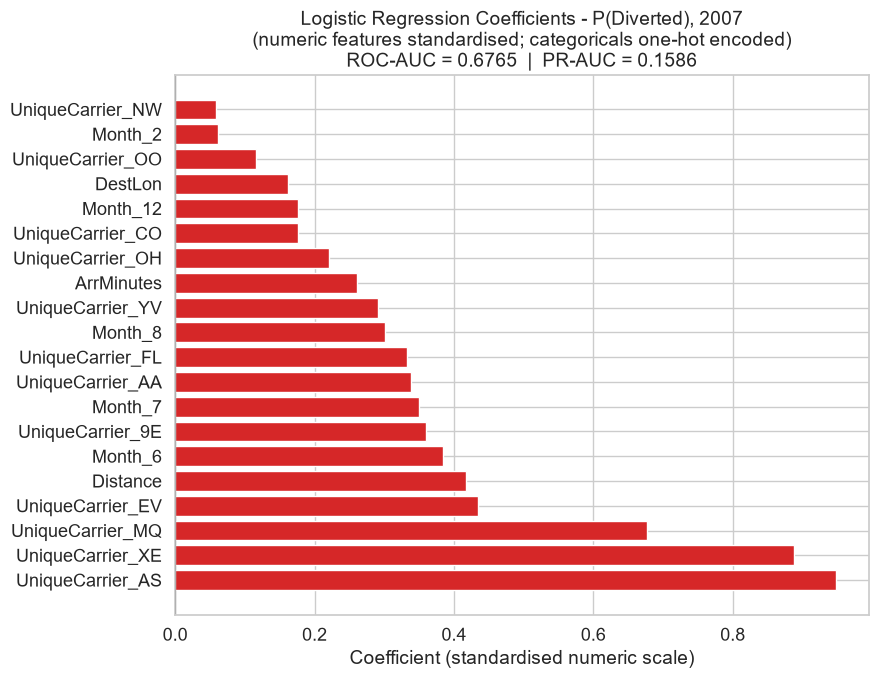

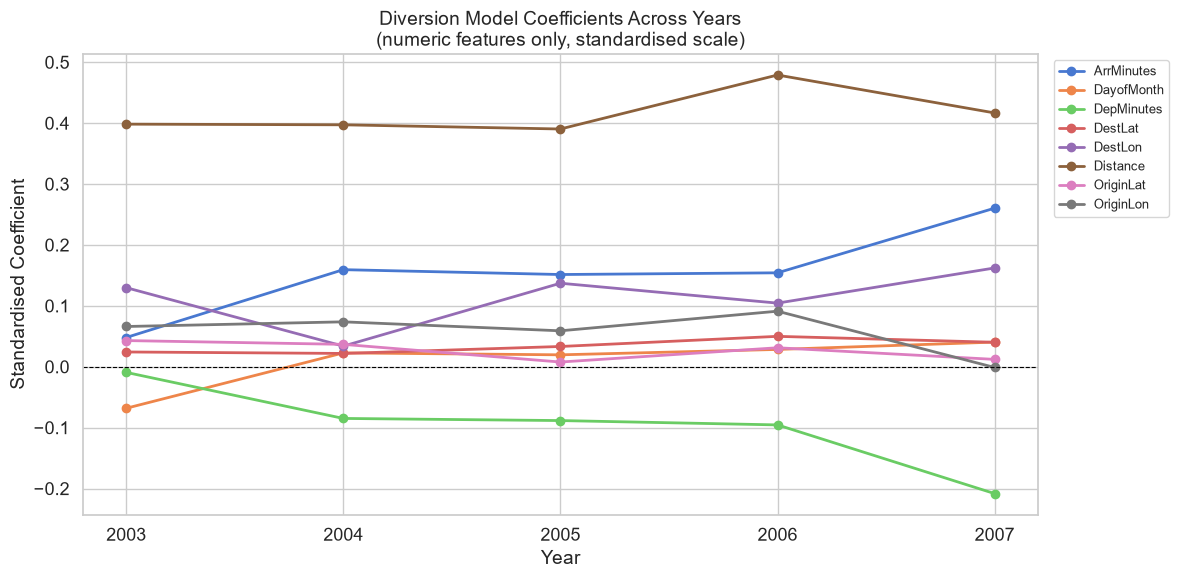


  Model metrics by year (test set):
    Year   ROC-AUC    PR-AUC  Baseline PR
  ------  --------  --------  -----------
    2003    0.6543    0.0971       0.0569
    2004    0.6460    0.1129       0.0689
    2005    0.6671    0.1255       0.0702
    2006    0.6664    0.1446       0.0809
    2007    0.6765    0.1586       0.0859

  SUMMARY  --  Best Day, Time Block & Combination by Year
  Year  Best Day  Best Block                Best Combo (Day + Block)                  Robust
  ----  --------  ------------------------  ----------------------------------------  ------
  2003       Sat  05-08  Early Morning      Sun + 05-08  Early Morning                NO
  2004       Sat  05-08  Early Morning      Sun + 05-08  Early Morning                YES
  2005       Sat  05-08  Early Morning      Sun + 05-08  Early Morning                YES
  2006       Sat  05-08  Early Morning      Sun + 05-08  Early Morning                YES
  2007       Sat  05-08  Early Morning      Sun + 05-08  Early Mo

In [9]:
DATA_DIR = "./data"

FLIGHT_FILES = [os.path.join(DATA_DIR, f"{yr}.csv") for yr in range(2003, 2008)]
PLANE_FILE   = os.path.join(DATA_DIR, "plane-data.csv")
AIRPORT_FILE = os.path.join(DATA_DIR, "airports.csv")
CARRIER_FILE = os.path.join(DATA_DIR, "carriers.csv")

results = run_analysis(
    flight_files = FLIGHT_FILES,
    plane_file   = PLANE_FILE,
    airport_file = AIRPORT_FILE,
    carrier_file = CARRIER_FILE,
)

# Conclusions

This analysis of the 2003–2007 US domestic flight data yields three primary insights:

* **Optimal timing:** To minimise delay probability, fly in the **early-morning block (05:00–08:00)** — the joint Sunday + early-morning combination has the lowest delay probability in every year, and Saturday is the best day in isolation. Delays compound as the day progresses, consistent with "knock-on" effects in the hub-and-spoke system.
* **Aircraft age:** There is a measurable positive association between aircraft age and delay probability, but it is modest (odds ratio ≈ 1.01–1.04 per +5 years of age). Once carrier-specific effects are controlled for through logistic regression, the carrier's operational performance matters more than the age of the airframe.
* **Predicting diversions:** A logistic regression on schedule features consistently beats the naive baseline (PR-AUC roughly 1.7–1.9× the diversion base rate), and identifies departure time and day of month as key signals. The extreme class imbalance (~0.2% positives) means the model is best used for flagging high-risk scenarios, with careful threshold tuning before any practical deployment.